Fetching MNIST dataset...
Subsampled Dataset Shape: (10000, 784)

Running Linear PCA...
PCA Reconstruction MSE: 0.0559
Running Kernel PCA (RBF)... This may take 1-2 minutes...
Kernel PCA Reconstruction MSE: 0.0631


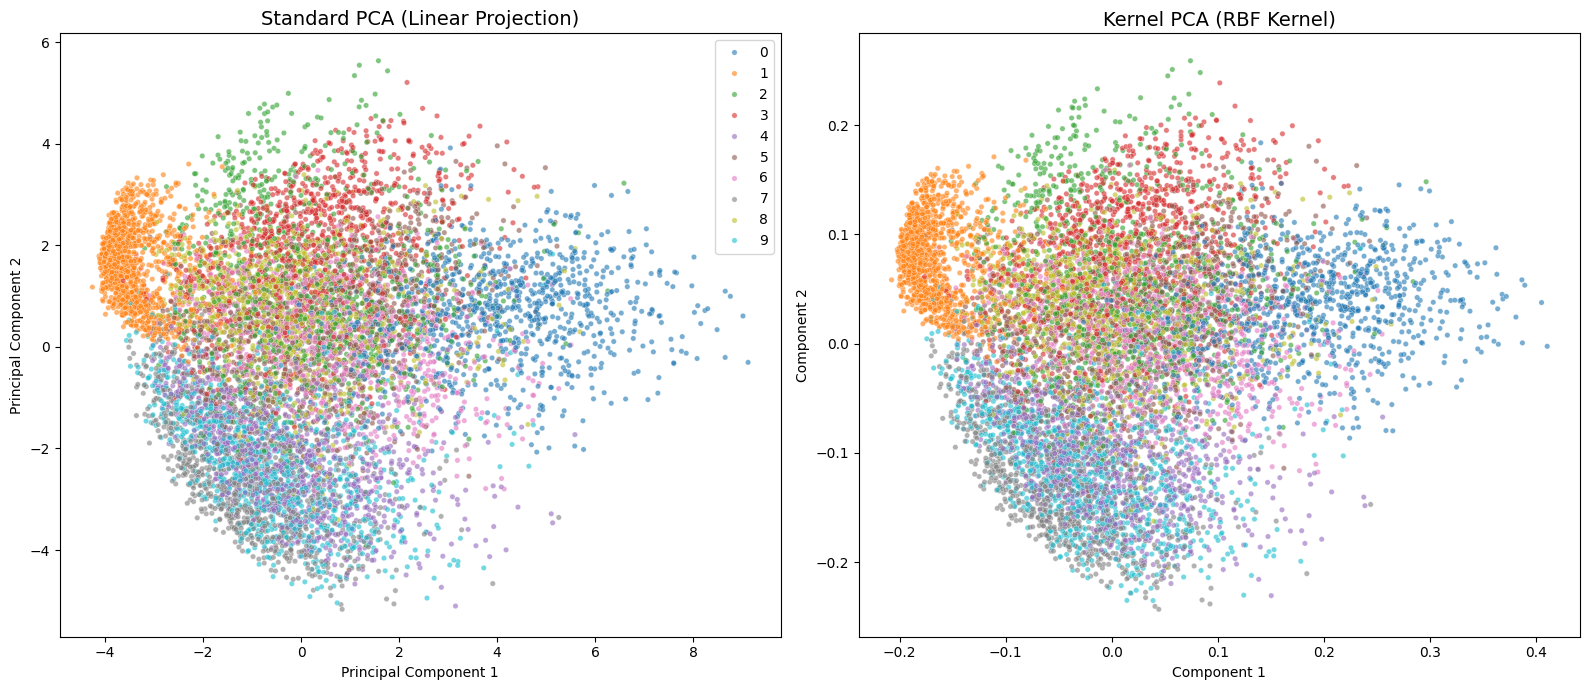

In [1]:
# --- QUESTION 3: DIMENSIONALITY REDUCTION ---

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Fetching MNIST dataset...")
# Load MNIST
X_full, y_full = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
y_full = y_full.astype(int)

# 1. Methodological Subsampling
# We take a stratified sample of 10,000 images to prevent KernelPCA from crashing RAM
X_sample, _, y_sample, _ = train_test_split(
    X_full, y_full, train_size=10000, stratify=y_full, random_state=RANDOM_SEED
)

# Normalize pixel values to [0, 1]
X_scaled = X_sample / 255.0

print(f"Subsampled Dataset Shape: {X_scaled.shape}")

# 2. PCA (Linear)
print("\nRunning Linear PCA...")
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

# Calculate Reconstruction Error for PCA
X_pca_reconstructed = pca.inverse_transform(X_pca)
mse_pca = mean_squared_error(X_scaled, X_pca_reconstructed)
print(f"PCA Reconstruction MSE: {mse_pca:.4f}")

# 3. Kernel PCA (RBF Kernel)
print("Running Kernel PCA (RBF)... This may take 1-2 minutes...")
# We must set fit_inverse_transform=True to calculate MSE later
kpca = KernelPCA(n_components=2, kernel='rbf', fit_inverse_transform=True, random_state=RANDOM_SEED, n_jobs=-1)
X_kpca = kpca.fit_transform(X_scaled)

# Calculate Reconstruction Error for Kernel PCA
X_kpca_reconstructed = kpca.inverse_transform(X_kpca)
mse_kpca = mean_squared_error(X_scaled, X_kpca_reconstructed)
print(f"Kernel PCA Reconstruction MSE: {mse_kpca:.4f}")

# 4. Visualise the 2D Embeddings
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
palette = sns.color_palette("tab10", 10)

# Plot PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_sample, palette=palette,
                legend='full', alpha=0.6, s=15, ax=axes[0])
axes[0].set_title('Standard PCA (Linear Projection)', fontsize=14)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Plot Kernel PCA
sns.scatterplot(x=X_kpca[:, 0], y=X_kpca[:, 1], hue=y_sample, palette=palette,
                legend=False, alpha=0.6, s=15, ax=axes[1])
axes[1].set_title('Kernel PCA (RBF Kernel)', fontsize=14)
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')

plt.tight_layout()
plt.show()

Starting Manifold Learning (This will take 5-7 minutes)...

Running t-SNE (Perplexity=5)...
Running t-SNE (Perplexity=30)...
Running t-SNE (Perplexity=50)...


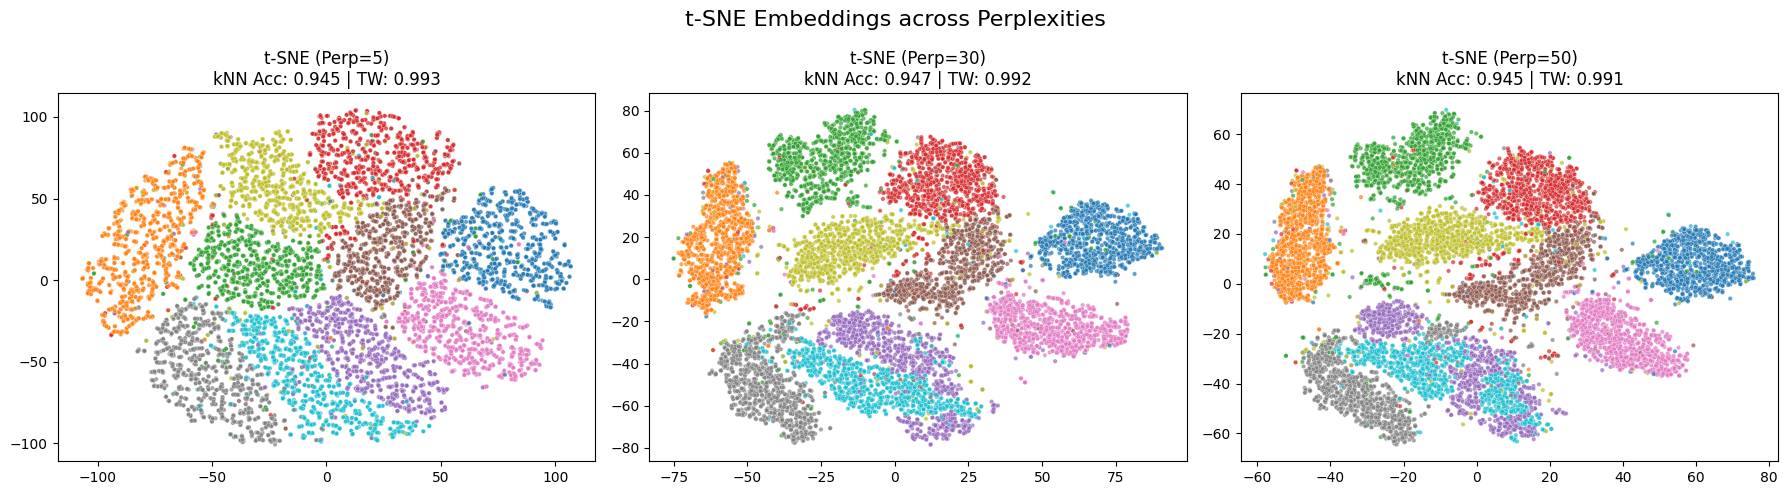


Running UMAP Tuning...
Running UMAP (n_neighbors=15, min_dist=0.1)...
Running UMAP (n_neighbors=50, min_dist=0.5)...


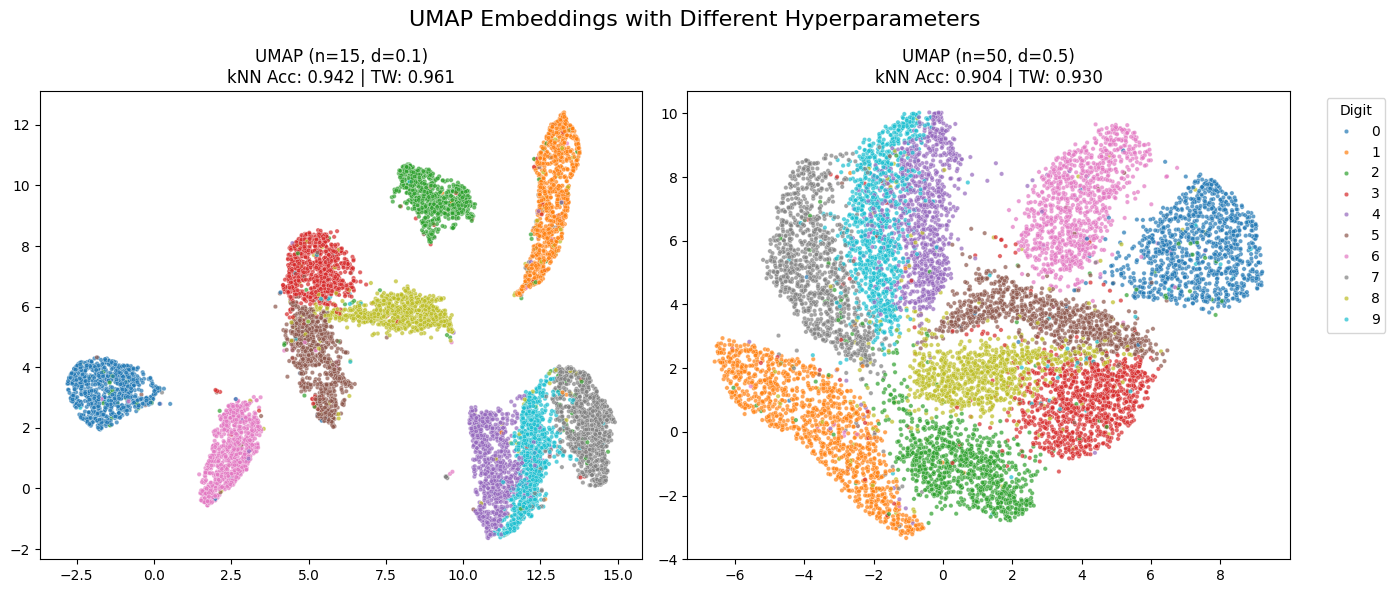


--- Downstream Metric Comparison ---
t-SNE (P= 5): kNN Acc: 0.9453 | Trust: 0.9929 | Stress: 0.4387 | Time: 155.0s
t-SNE (P=30): kNN Acc: 0.9474 | Trust: 0.9917 | Stress: 0.4340 | Time: 164.9s
t-SNE (P=50): kNN Acc: 0.9446 | Trust: 0.9907 | Stress: 0.4318 | Time: 178.1s
UMAP (n=15, d=0.1): kNN Acc: 0.9419 | Trust: 0.9608 | Stress: 0.4892 | Time: 64.3s
UMAP (n=50, d=0.5): kNN Acc: 0.9040 | Trust: 0.9304 | Stress: 0.4374 | Time: 49.8s


In [2]:
# Install UMAP
!pip install -q umap-learn

import umap
from sklearn.manifold import TSNE, trustworthiness
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from scipy.spatial.distance import pdist
import time

print("Starting Manifold Learning (This will take 5-7 minutes)...\n")

# --- Helper Function for Kruskal's Stress ---
def calculate_kruskal_stress(X_orig, X_embedded, sample_size=1000):
    """Calculates Kruskal's Stress on a subset to prevent RAM explosion."""
    idx = np.random.choice(X_orig.shape[0], sample_size, replace=False)
    d_orig = pdist(X_orig[idx])
    d_emb = pdist(X_embedded[idx])

    # Scale embeddings distance to match original scale roughly
    ratio = d_orig.sum() / d_emb.sum()
    d_emb_scaled = d_emb * ratio

    stress = np.sqrt(np.sum((d_orig - d_emb_scaled)**2) / np.sum(d_orig**2))
    return stress

# 1. t-SNE with Perplexity Grid Search
perplexities = [5, 30, 50]
tsne_results = {}

fig_tsne, axes_tsne = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette("tab10", 10)

for i, p in enumerate(perplexities):
    print(f"Running t-SNE (Perplexity={p})...")
    start = time.time()
    tsne = TSNE(n_components=2, perplexity=p, random_state=RANDOM_SEED, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_scaled)

    # Calculate Metrics
    tw = trustworthiness(X_scaled, X_tsne, n_neighbors=5)
    stress = calculate_kruskal_stress(X_scaled, X_tsne)

    # Downstream k-NN (k=5)
    knn = KNeighborsClassifier(n_neighbors=5)
    acc = cross_val_score(knn, X_tsne, y_sample, cv=5, n_jobs=-1).mean()

    tsne_results[p] = {'Trustworthiness': tw, 'Stress': stress, 'kNN_Acc': acc, 'Time': time.time() - start}

    # Plot
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sample, palette=palette, legend=False, s=10, alpha=0.7, ax=axes_tsne[i])
    axes_tsne[i].set_title(f't-SNE (Perp={p})\nkNN Acc: {acc:.3f} | TW: {tw:.3f}')

plt.suptitle("t-SNE Embeddings across Perplexities", fontsize=16)
plt.tight_layout()
plt.show()

# 2. UMAP Tuning
print("\nRunning UMAP Tuning...")
# Testing a couple of configurations as requested
umap_configs = [(15, 0.1), (50, 0.5)]
umap_results = {}

fig_umap, axes_umap = plt.subplots(1, 2, figsize=(14, 6))

for i, (n_n, m_d) in enumerate(umap_configs):
    print(f"Running UMAP (n_neighbors={n_n}, min_dist={m_d})...")
    start = time.time()
    reducer = umap.UMAP(n_neighbors=n_n, min_dist=m_d, random_state=RANDOM_SEED)
    X_umap = reducer.fit_transform(X_scaled)

    # Calculate Metrics
    tw = trustworthiness(X_scaled, X_umap, n_neighbors=5)
    stress = calculate_kruskal_stress(X_scaled, X_umap)

    # Downstream k-NN (k=5)
    knn = KNeighborsClassifier(n_neighbors=5)
    acc = cross_val_score(knn, X_umap, y_sample, cv=5, n_jobs=-1).mean()

    umap_results[f"n={n_n}, d={m_d}"] = {'Trustworthiness': tw, 'Stress': stress, 'kNN_Acc': acc, 'Time': time.time() - start}

    # Plot
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_sample, palette=palette, legend=(i==1), s=10, alpha=0.7, ax=axes_umap[i])
    axes_umap[i].set_title(f'UMAP (n={n_n}, d={m_d})\nkNN Acc: {acc:.3f} | TW: {tw:.3f}')

if axes_umap[1].get_legend():
    axes_umap[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Digit")

plt.suptitle("UMAP Embeddings with Different Hyperparameters", fontsize=16)
plt.tight_layout()
plt.show()

# Print Final Comparison Table
print("\n--- Downstream Metric Comparison ---")
for p, res in tsne_results.items():
    print(f"t-SNE (P={p:2}): kNN Acc: {res['kNN_Acc']:.4f} | Trust: {res['Trustworthiness']:.4f} | Stress: {res['Stress']:.4f} | Time: {res['Time']:.1f}s")
for conf, res in umap_results.items():
    print(f"UMAP ({conf}): kNN Acc: {res['kNN_Acc']:.4f} | Trust: {res['Trustworthiness']:.4f} | Stress: {res['Stress']:.4f} | Time: {res['Time']:.1f}s")

Building and Training the Autoencoder (This will take ~1-2 minutes)...

Autoencoder Reconstruction MSE: 0.0472


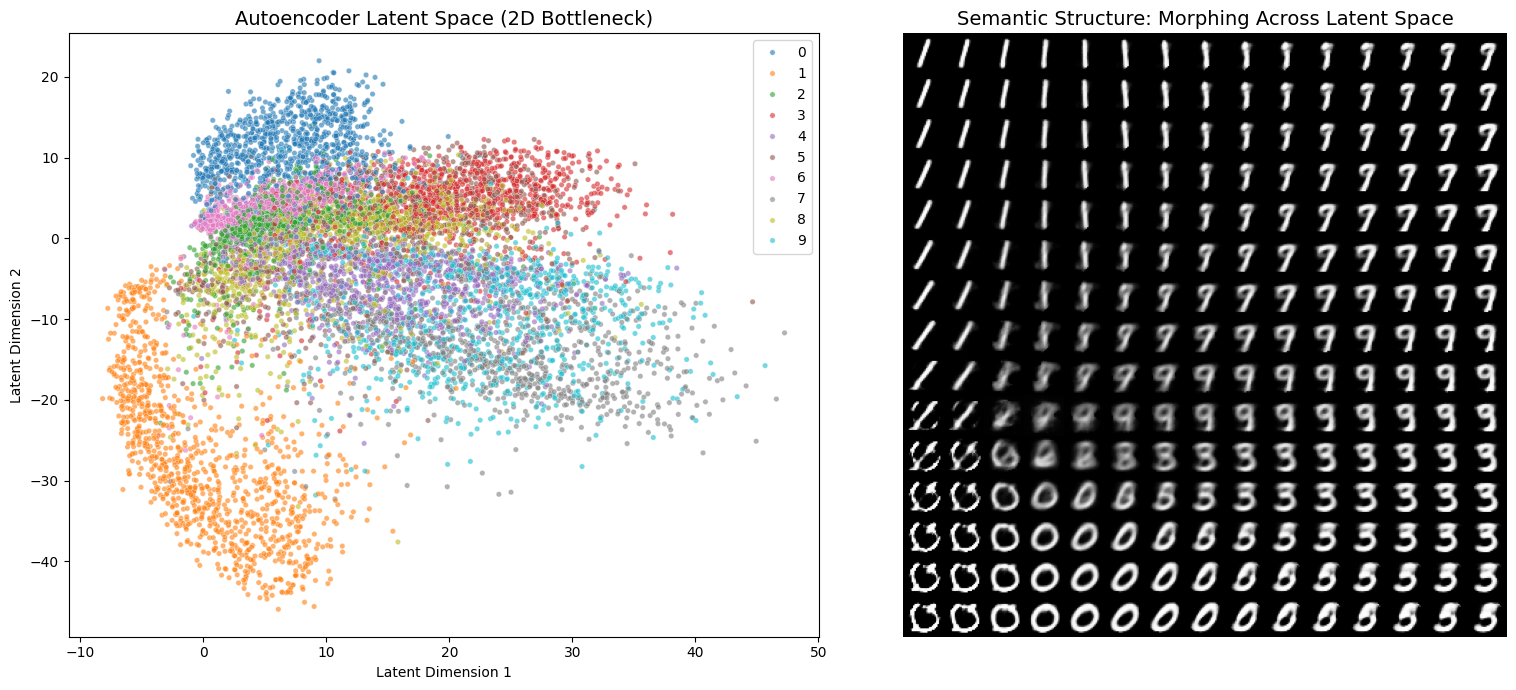

In [3]:
# 5. Undercomplete Autoencoder
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("Building and Training the Autoencoder (This will take ~1-2 minutes)...\n")

# Define the Architecture (784 -> 128 -> 2 -> 128 -> 784)
input_img = layers.Input(shape=(784,))
# Encoder
encoded = layers.Dense(128, activation='relu')(input_img)
# Bottleneck (2 dimensions for visualisation)
bottleneck = layers.Dense(2, activation='linear')(encoded)
# Decoder
decoded = layers.Dense(128, activation='relu')(bottleneck)
output_img = layers.Dense(784, activation='sigmoid')(decoded)

# Create the full autoencoder and the encoder-only model
autoencoder = models.Model(input_img, output_img)
encoder = models.Model(input_img, bottleneck)

autoencoder.compile(optimizer='adam', loss='mse')

# Train the model
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=0 # Suppressing epoch-by-epoch text output for cleanliness
)

# 5a. Quantitative Evaluation (MSE)
X_ae_reconstructed = autoencoder.predict(X_scaled, verbose=0)
mse_ae = mean_squared_error(X_scaled, X_ae_reconstructed)
print(f"Autoencoder Reconstruction MSE: {mse_ae:.4f}")

# Extract the 2D embeddings for the entire sample
X_latent = encoder.predict(X_scaled, verbose=0)

# 5b. Visualise the Latent Space Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
palette = sns.color_palette("tab10", 10)

sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=y_sample, palette=palette,
                legend='full', alpha=0.6, s=15, ax=axes[0])
axes[0].set_title('Autoencoder Latent Space (2D Bottleneck)', fontsize=14)
axes[0].set_xlabel('Latent Dimension 1')
axes[0].set_ylabel('Latent Dimension 2')

# 5c. Visualise Semantic Structure (Decoding a 2D Grid)
# We create a grid of coordinates and ask the decoder to generate images from them
n_grid = 15
digit_size = 28
figure = np.zeros((digit_size * n_grid, digit_size * n_grid))

# Create a linearly spaced grid based on the min/max of our actual latent variables
grid_x = np.linspace(np.min(X_latent[:, 0]), np.max(X_latent[:, 0]), n_grid)
grid_y = np.linspace(np.min(X_latent[:, 1]), np.max(X_latent[:, 1]), n_grid)

# We need the decoder part of the model specifically
decoder_input = layers.Input(shape=(2,))
dec_layer1 = autoencoder.layers[-2](decoder_input)
dec_layer2 = autoencoder.layers[-1](dec_layer1)
decoder = models.Model(decoder_input, dec_layer2)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

axes[1].imshow(figure, cmap='Greys_r')
axes[1].set_title('Semantic Structure: Morphing Across Latent Space', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()